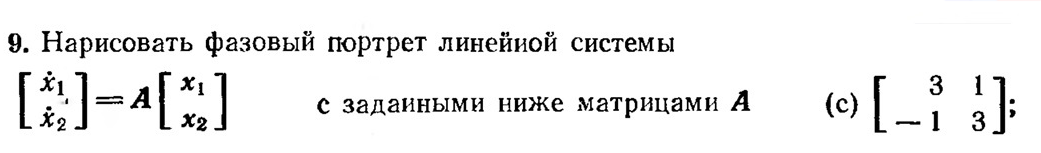

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp

# визначення власних значень
A = sp.Matrix([[3,1],[-1,3]])
eigs = A.eigenvects()
print('Власні числа матриці А:', eigs[0][0], eigs[1][0], sep = '\n')

Власні числа матриці А:
3 - I
3 + I


In [2]:
# аналітичний загальний розв'язок через матричну експоненту
t = sp.symbols('t', real=True)
expAt = sp.exp(A*t)
print(sp.simplify(expAt))

Matrix([[exp(3*t)*cos(t), exp(3*t)*sin(t)], [-exp(3*t)*sin(t), exp(3*t)*cos(t)]])


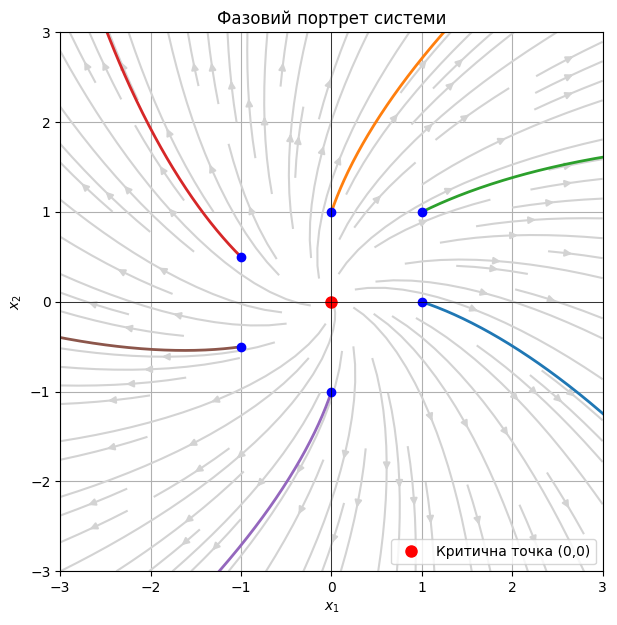

In [3]:
# Матриця системи
A = np.array([[3., 1.], [-1., 3.]])

# Векторна функція системи
def f(t, x):
    return A.dot(x)

# Сітка для напрямного поля
xmin, xmax = -3, 3
ymin, ymax = -3, 3
nx, ny = 25, 25
x = np.linspace(xmin, xmax, nx)
y = np.linspace(ymin, ymax, ny)
X, Y = np.meshgrid(x, y)
U = 3*X + 1*Y      # ẋ1
V = -1*X + 3*Y     # ẋ2

# Напрямне поле
plt.figure(figsize=(7,7))
plt.streamplot(X, Y, U, V, density=1.0, color='lightgray')

# Список початкових умов для траєкторій
x0_list = [[1, 0], [0, 1], [1, 1], [-1, 0.5], [0, -1], [-1, -0.5]]

# Час інтегрування
t_span = (0, 1)
t_eval = np.linspace(*t_span, 300)

# Малювання траєкторій
for x0 in x0_list:
    sol = solve_ivp(f, t_span, x0, t_eval=t_eval)
    plt.plot(sol.y[0], sol.y[1], linewidth=2)
    plt.plot(x0[0], x0[1], 'o', color='blue')  # початкові точки

# Особлива точка
plt.plot(0, 0, 'o', color='red', markersize=8, label='Критична точка (0,0)')

# Налаштування осей та сітки
plt.axhline(0, linewidth=0.5, color='black')
plt.axvline(0, linewidth=0.5, color='black')
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Фазовий портрет системи')
plt.legend()
plt.grid(True)
plt.show()
